<a href="https://colab.research.google.com/github/pedrosouza013/-banco-de-dados1/blob/main/C%C3%B3pia_de_3ds_transforma%C3%A7%C3%A3o_de_variaveis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importa bibliotecas necessárias do Python
import pandas as pd   # Manipulação de dados em tabelas
import numpy as np    # Operações matemáticas e estatísticas
import matplotlib.pyplot as plt   # Criação de gráficos básicos
import seaborn as sns   # Visualizações estatísticas mais elaboradas

# ==============================================================================
# 1. CENÁRIO DO MUNDO REAL: Crescimento de Usuários de um Novo Aplicativo
# ==============================================================================
# Imagine que nosso aplicativo começou com 100 usuários e, a cada mês,
# esse número cresce cerca de 40% em relação ao mês anterior (crescimento viral).

meses = np.arange(1, 25) # Simulando 2 anos de funcionamento (mês 1 ao 24)
usuarios_iniciais = 100
taxa_crescimento = 1.40

# Calculando o crescimento exponencial mês a mês: 100 * (1.40 ^ mês)
usuarios_reais = usuarios_iniciais * (taxa_crescimento ** meses)

# Criando a nossa tabela (DataFrame) de forma organizada
dados_app = pd.DataFrame({
    'Mes': meses,
    'Total_Usuarios': usuarios_reais
})

# Visualiza a tabela
dados_app


,Mes,Total_Usuarios
0,1,140.000000
1,2,196.000000
2,3,274.400000
3,4,384.160000
4,5,537.824000
5,6,752.953600
6,7,1054.135040
7,8,1475.789056
8,9,2066.104678
9,10,2892.546550


In [2]:
# ==============================================================================
# 2. POR QUE PRECISAMOS DA TRANSFORMAÇÃO? (O Problema)
# ==============================================================================
# No começo, o app cresce devagar (de 100 para 140). Mas no final, o salto é gigante
# (vai de 1 milhão para 1.4 milhão em um único mês).
# Em um gráfico normal, os primeiros meses pareceriam uma linha reta no zero,
# dificultando ver se o crescimento no início foi bom ou ruim.

# Aplicamos o Logaritmo para "achatar" a escala e focar na taxa de crescimento percentual
dados_app['Log_Usuarios'] = np.log(dados_app['Total_Usuarios'])

# Visualiza a tabela com transformação das variáveis
dados_app.head(10)

,Mes,Total_Usuarios,Log_Usuarios
0,1,140.000000,4.941642
1,2,196.000000,5.278115
2,3,274.400000,5.614587
3,4,384.160000,5.951059
4,5,537.824000,6.287531
5,6,752.953600,6.624004
6,7,1054.135040,6.960476
7,8,1475.789056,7.296948
8,9,2066.104678,7.633420
9,10,2892.546550,7.969893


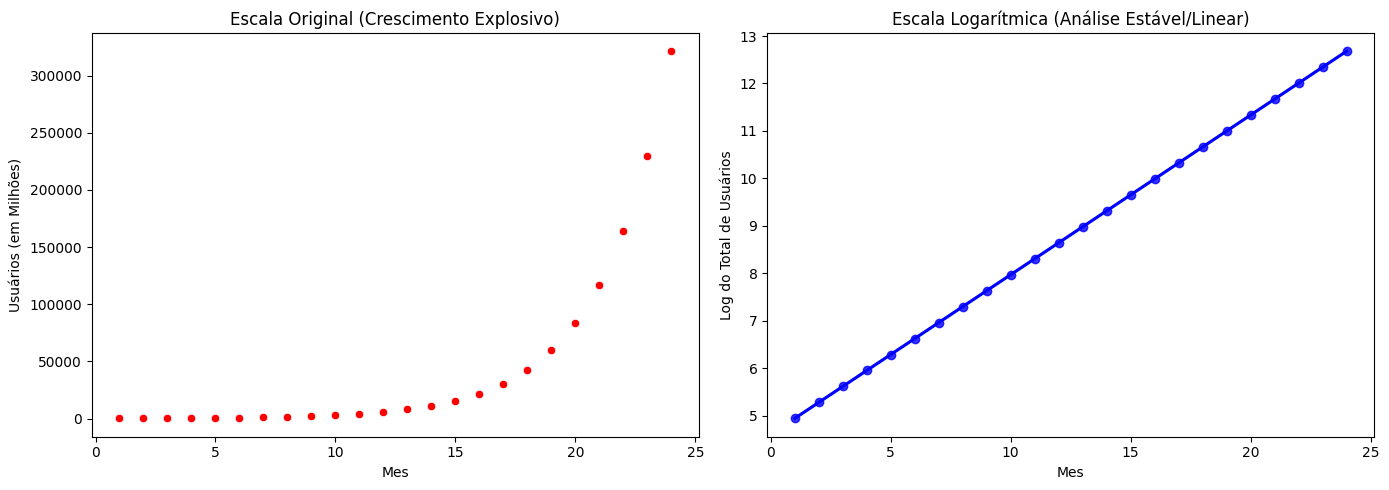

In [3]:
# ==============================================================================
# 3. CRIANDO OS GRÁFICOS PARA COMPARAR (Visualização Prática)
# ==============================================================================
# Vamos criar duas imagens lado a lado para ver a diferença brutal.
fig, visualizacoes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Dados Originais (Escala Real)
# Mostra o "boom" do crescimento, mas esconde o histórico do primeiro ano.
sns.scatterplot(x='Mes', y='Total_Usuarios', data=dados_app, ax=visualizacoes[0], color='red')
visualizacoes[0].set_title('Escala Original (Crescimento Explosivo)')
visualizacoes[0].set_ylabel('Usuários (em Milhões)')

# Gráfico 2: Dados Transformados com Logaritmo (Relação Linear)
# Transforma a curva em uma linha reta perfeita. Aqui, cada centímetro vertical
# representa o mesmo ganho percentual (40%), permitindo analisar todo o histórico igualmente.
sns.regplot(x='Mes', y='Log_Usuarios', data=dados_app, ax=visualizacoes[1], color='blue')
visualizacoes[1].set_title('Escala Logarítmica (Análise Estável/Linear)')
visualizacoes[1].set_ylabel('Log do Total de Usuários')

plt.tight_layout()
plt.show()